# Review High Confidence Style Genre Artist Rerun

Review notebook for `high_confidence_style_genre_artist.csv`.


In [1]:
from pathlib import Path
import pandas as pd

repo_root = Path.cwd().resolve()
if not (repo_root / 'notebooks_rerun').exists():
    repo_root = repo_root.parent

csv_path = repo_root / 'notebooks_rerun' / 'high_confidence_style_genre_artist.csv'
df = pd.read_csv(csv_path).sort_values('mean_confidence', ascending=False).reset_index(drop=True)

print(f'CSV path: {csv_path}')
print(f'Rows: {len(df)}')
print(f'Columns: {len(df.columns)}')
print('Incorrect task counts:')
print(df['incorrect_tasks'].fillna('none').value_counts().to_string())


CSV path: /Users/Lenovo/Desktop/sem 6/Gsoc_HumanAi/notebooks_rerun/high_confidence_style_genre_artist.csv
Rows: 3
Columns: 22
Incorrect task counts:
incorrect_tasks
style,genre,artist    3


In [2]:
top_columns = ['image_path', 'incorrect_tasks', 'style_true_name', 'style_pred_name', 'style_confidence', 'genre_true_name', 'genre_pred_name', 'genre_confidence', 'artist_true_name', 'artist_pred_name', 'artist_confidence', 'mean_confidence']

top20 = df.loc[:19, top_columns].copy()
top20.index = top20.index + 1
top20


,image_path,incorrect_tasks,style_true_name,style_pred_name,style_confidence,genre_true_name,genre_pred_name,genre_confidence,artist_true_name,artist_pred_name,artist_confidence,mean_confidence
1,Realism/camille-pissarro_a-creek-in-saint-thom...,"style,genre,artist",Realism,Romanticism,0.956924,genre_painting,landscape,0.95673,Camille_Pissarro,Ivan_Aivazovsky,0.987753,0.967136
2,Realism/salvador-dali_gala-contemplate-corpus-...,"style,genre,artist",Realism,Northern_Renaissance,0.997322,portrait,religious_painting,0.92574,Salvador_Dali,Albrecht_Durer,0.972944,0.965335
3,Romanticism/gustave-dore_edward-i-of-england-k...,"style,genre,artist",Romanticism,Northern_Renaissance,0.957752,illustration,religious_painting,0.96831,Gustave_Dore,Albrecht_Durer,0.962744,0.962936


In [3]:
style_genre_artist_rows = df[['image_path', 'incorrect_tasks', 'style_true_name', 'style_pred_name', 'style_confidence', 'genre_true_name', 'genre_pred_name', 'genre_confidence', 'artist_true_name', 'artist_pred_name', 'artist_confidence', 'mean_confidence']].head(20).copy()
style_genre_artist_rows.index = style_genre_artist_rows.index + 1
style_genre_artist_rows


,image_path,incorrect_tasks,style_true_name,style_pred_name,style_confidence,genre_true_name,genre_pred_name,genre_confidence,artist_true_name,artist_pred_name,artist_confidence,mean_confidence
1,Realism/camille-pissarro_a-creek-in-saint-thom...,"style,genre,artist",Realism,Romanticism,0.956924,genre_painting,landscape,0.95673,Camille_Pissarro,Ivan_Aivazovsky,0.987753,0.967136
2,Realism/salvador-dali_gala-contemplate-corpus-...,"style,genre,artist",Realism,Northern_Renaissance,0.997322,portrait,religious_painting,0.92574,Salvador_Dali,Albrecht_Durer,0.972944,0.965335
3,Romanticism/gustave-dore_edward-i-of-england-k...,"style,genre,artist",Romanticism,Northern_Renaissance,0.957752,illustration,religious_painting,0.96831,Gustave_Dore,Albrecht_Durer,0.962744,0.962936


thumbnail,image_path,incorrect_tasks,style_true_name,style_pred_name,genre_true_name,genre_pred_name,artist_true_name,artist_pred_name,mean_confidence
,Realism/camille-pissarro_a-creek-in-saint-thomas-antilles-1856.jpg,"style,genre,artist",Realism,Romanticism,genre_painting,landscape,Camille_Pissarro,Ivan_Aivazovsky,0.967136
,Realism/salvador-dali_gala-contemplate-corpus-hypercubus.jpg,"style,genre,artist",Realism,Northern_Renaissance,portrait,religious_painting,Salvador_Dali,Albrecht_Durer,0.965335
,Romanticism/gustave-dore_edward-i-of-england-kills-his-would-be-assassin-in-june-1272-1877.jpg,"style,genre,artist",Romanticism,Northern_Renaissance,illustration,religious_painting,Gustave_Dore,Albrecht_Durer,0.962936

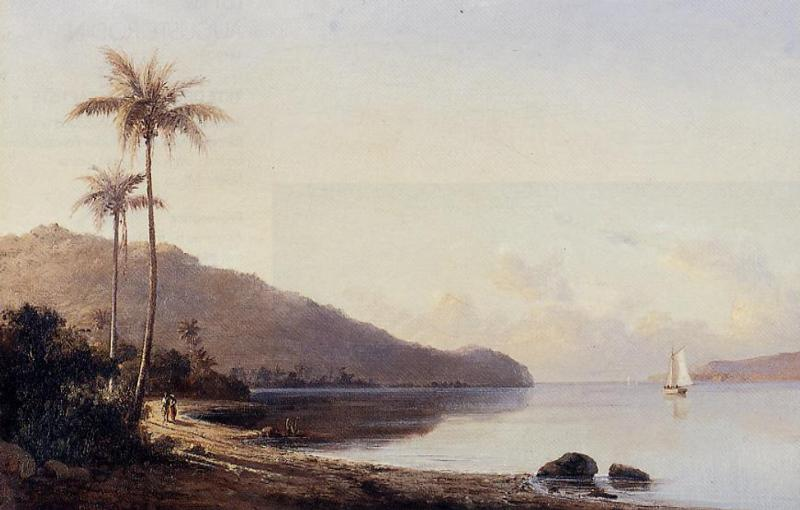
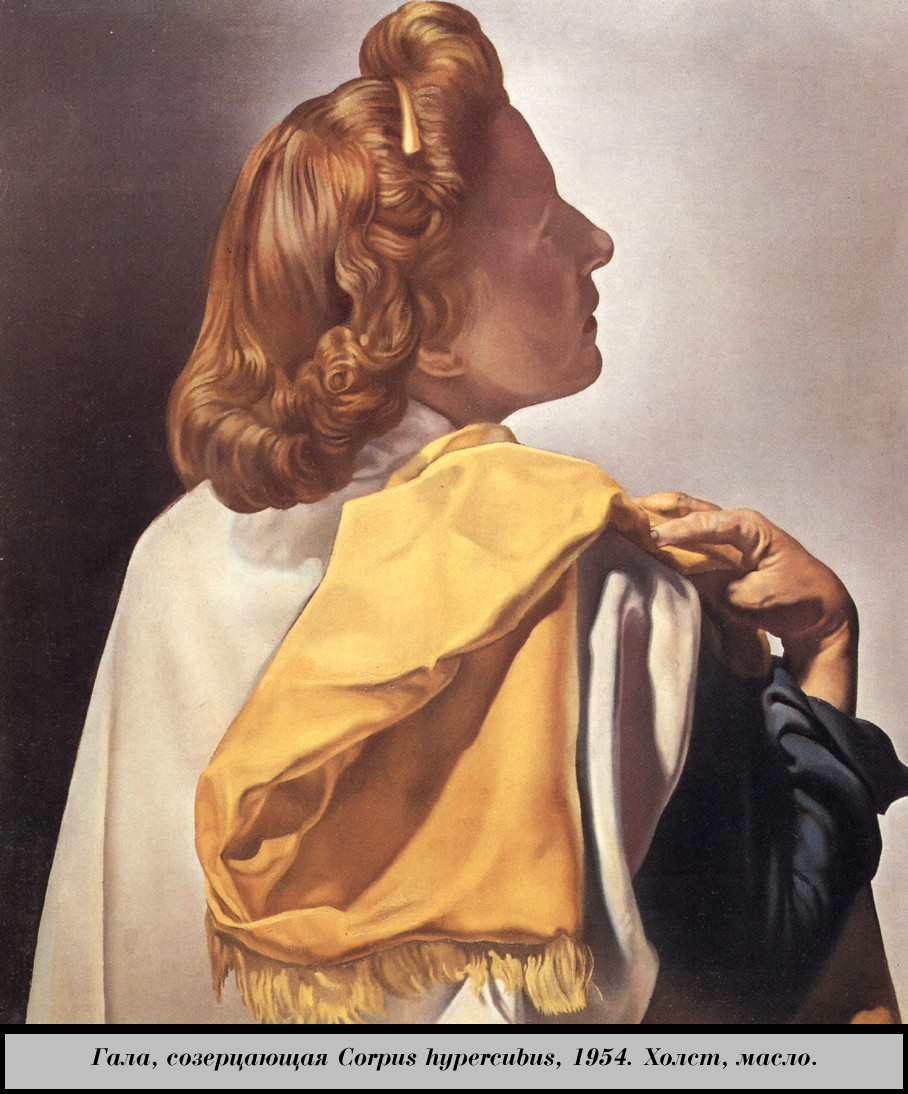
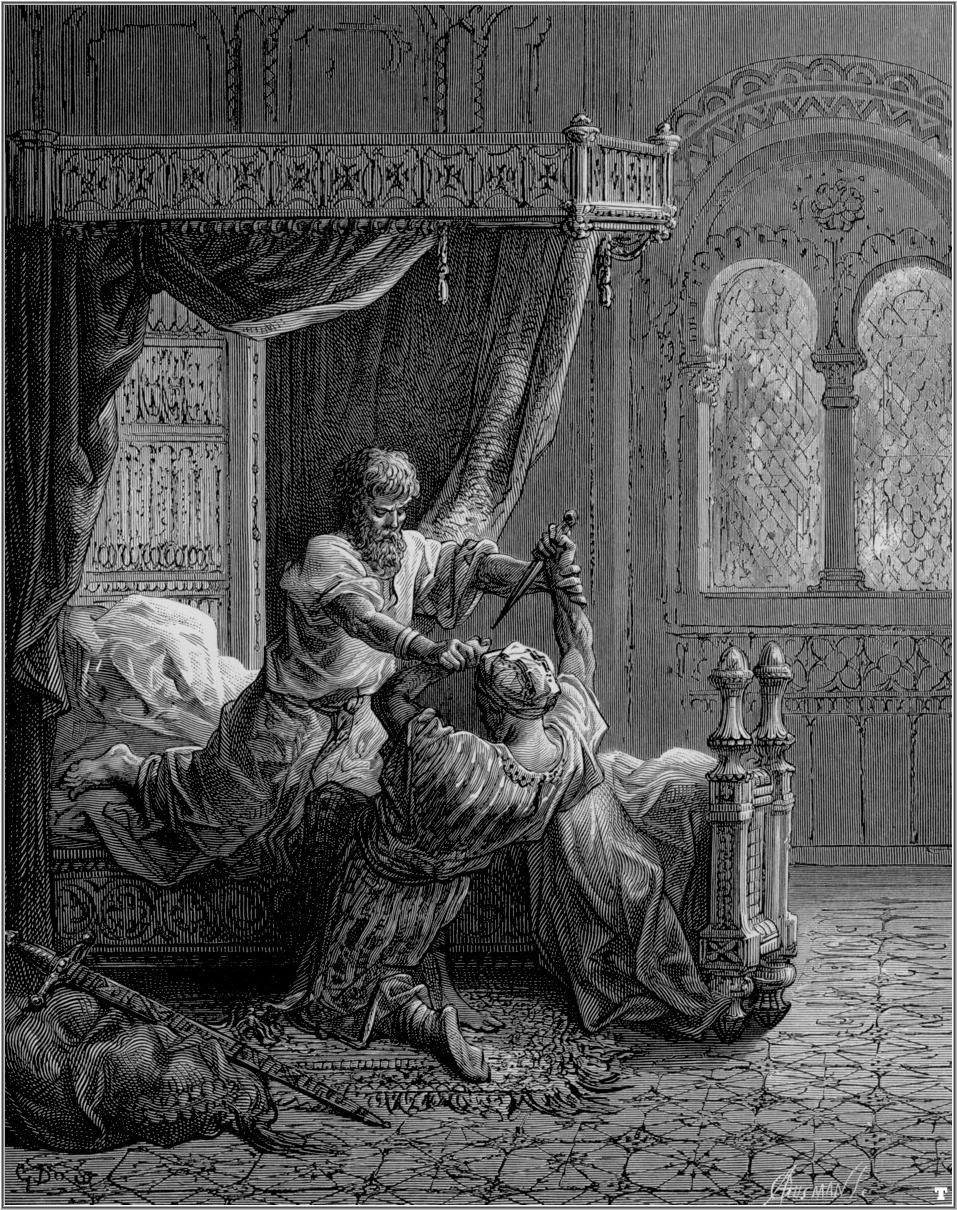

In [4]:
import base64

class HtmlDisplay(str):
    def _repr_html_(self):
        return str(self)

def image_tag(relative_path: str, width: int = 120) -> str:
    image_path = repo_root / 'data' / 'wikiart' / relative_path
    if not image_path.exists():
        return '<span style="color:#b00;">missing</span>'
    encoded = base64.b64encode(image_path.read_bytes()).decode('ascii')
    suffix = image_path.suffix.lower().lstrip('.') or 'jpeg'
    mime = 'image/jpeg' if suffix == 'jpg' else f'image/{suffix}'
    return f'<img src="data:{mime};base64,{encoded}" width="{width}" />'

review_template = df.loc[:19, ['image_path', 'incorrect_tasks', 'style_true_name', 'style_pred_name', 'genre_true_name', 'genre_pred_name', 'artist_true_name', 'artist_pred_name', 'mean_confidence']].copy()
review_template.insert(0, 'thumbnail', review_template['image_path'].map(image_tag))
HtmlDisplay(review_template.to_html(escape=False, index=False))
